# **1. Load Dataset**

In [2]:
#menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
import pandas as pd
path = '/content/gdrive/MyDrive/Machine Learning/Pertemuan6/Tugas/data/Spiral.txt'

df = pd.read_csv(path, sep=r'\s+', header=None, names=['x1', 'x2', 'label'], skiprows=7)
df.head()

,x1,x2,label
0,31.95,7.95,3
1,31.15,7.30,3
2,30.45,6.65,3
3,29.70,6.00,3
4,28.90,5.55,3


# **2. EDA – Cek Info Data**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      312 non-null    float64
 1   x2      312 non-null    float64
 2   label   312 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 7.4 KB


In [5]:
df.describe()

,x1,x2,label
count,312.000000,312.000000,312.000000
mean,18.408173,16.344712,2.016026
std,7.299923,6.867232,0.815682
min,3.000000,2.900000,1.000000
25%,12.912500,11.337500,1.000000
50%,18.325000,16.050000,2.000000
75%,23.400000,21.362500,3.000000
max,31.950000,31.650000,3.000000


In [15]:
print("\nJumlah Kelas:")
print(df['label'].value_counts())


Jumlah Kelas:
label
3    106
2    105
1    101
Name: count, dtype: int64


# **3. Pisahkan Fitur & Label**

In [16]:
# Pisahkan fitur (X) dan label (y)
X = df[['x1', 'x2']]   # sesuaikan jika nama kolom berbeda
y = df['label']

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (312, 2)
Shape y: (312,)


# **4. Split Data menjadi Train & Test**

In [17]:
from sklearn.model_selection import train_test_split

# Bagi data menjadi 80% train dan 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing :", len(X_test))

Jumlah data training: 249
Jumlah data testing : 63


# **5. Scaling Data**

In [18]:
from sklearn.preprocessing import StandardScaler

# Lakukan Standard Scaler pada data train & test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling berhasil dilakukan!")

Scaling berhasil dilakukan!


# **6. SVM Kernel Linear**

**Training & Prediksi Model Linear**

In [19]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Training model SVM dengan kernel Linear
model_linear = SVC(kernel='linear')
model_linear.fit(X_train_scaled, y_train)

# Prediksi menggunakan model Linear
y_pred_linear = model_linear.predict(X_test_scaled)

print("Akurasi Model SVM Linear:", accuracy_score(y_test, y_pred_linear))

Akurasi Model SVM Linear: 0.2698412698412698


**Classification Report Linear**

In [20]:
from sklearn.metrics import classification_report

print("=== Classification Report - SVM Linear ===")
print(classification_report(y_test, y_pred_linear))

=== Classification Report - SVM Linear ===
              precision    recall  f1-score   support

           1       0.26      0.25      0.26        20
           2       0.32      0.33      0.33        21
           3       0.23      0.23      0.23        22

    accuracy                           0.27        63
   macro avg       0.27      0.27      0.27        63
weighted avg       0.27      0.27      0.27        63



**Confusion Matrix Linear**

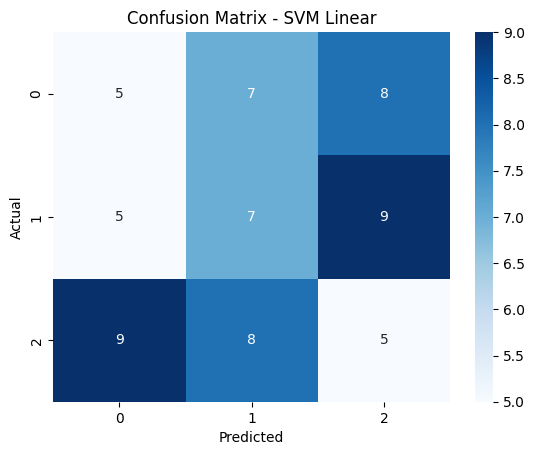

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_linear = confusion_matrix(y_test, y_pred_linear)

sns.heatmap(cm_linear, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM Linear")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **7. SVM Kernel RBF**

**Training & Prediksi Model RBF**

In [22]:
# Training model SVM dengan kernel RBF
model_rbf = SVC(kernel='rbf', gamma='auto')
model_rbf.fit(X_train_scaled, y_train)

# Prediksi menggunakan model RBF
y_pred_rbf = model_rbf.predict(X_test_scaled)

print("Akurasi Model SVM RBF:", accuracy_score(y_test, y_pred_rbf))

Akurasi Model SVM RBF: 1.0


**Classification Report RBF**

In [23]:
print("=== Classification Report - SVM RBF ===")
print(classification_report(y_test, y_pred_rbf))

=== Classification Report - SVM RBF ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        21
           3       1.00      1.00      1.00        22

    accuracy                           1.00        63
   macro avg       1.00      1.00      1.00        63
weighted avg       1.00      1.00      1.00        63



**Confusion Matrix RBF**

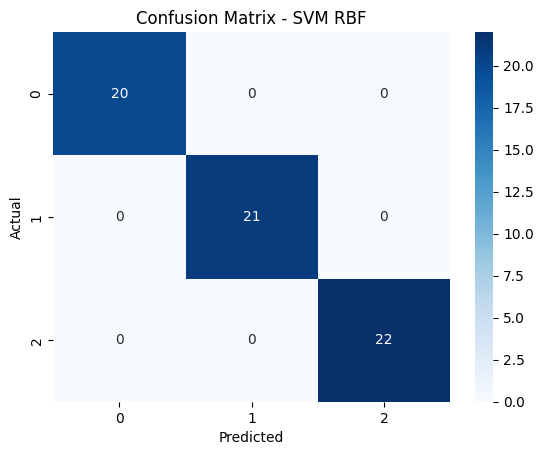

In [24]:
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

sns.heatmap(cm_rbf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM RBF")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **8. SVM Kernel Polynomial**

**Training & Prediksi Model Polynomial**

In [25]:
# Training model SVM dengan kernel Polynomial
model_poly = SVC(kernel='poly', degree=3)  # degree bisa diubah ke 2, 3, atau 4
model_poly.fit(X_train_scaled, y_train)

# Prediksi menggunakan model Polynomial
y_pred_poly = model_poly.predict(X_test_scaled)

print("Akurasi Model SVM Polynomial:", accuracy_score(y_test, y_pred_poly))

Akurasi Model SVM Polynomial: 0.3968253968253968


**Classification Report Polynomial**

In [26]:
print("=== Classification Report - SVM Polynomial ===")
print(classification_report(y_test, y_pred_poly))

=== Classification Report - SVM Polynomial ===
              precision    recall  f1-score   support

           1       0.34      0.55      0.42        20
           2       0.50      0.38      0.43        21
           3       0.40      0.27      0.32        22

    accuracy                           0.40        63
   macro avg       0.41      0.40      0.39        63
weighted avg       0.42      0.40      0.39        63



**Confusion Matrix Polynomial**

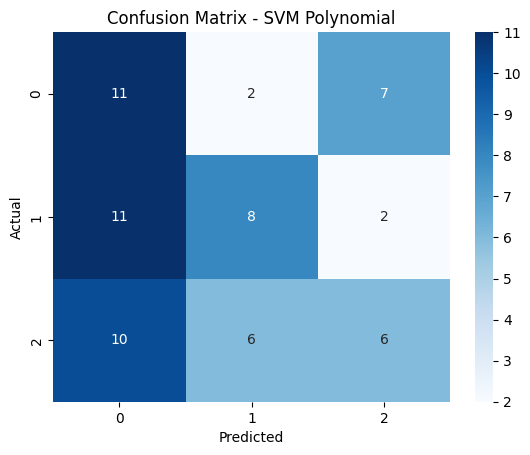

In [27]:
cm_poly = confusion_matrix(y_test, y_pred_poly)

sns.heatmap(cm_poly, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM Polynomial")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **9. 2D Visualisasi SVM (Linear, RBF, Polynomial)**

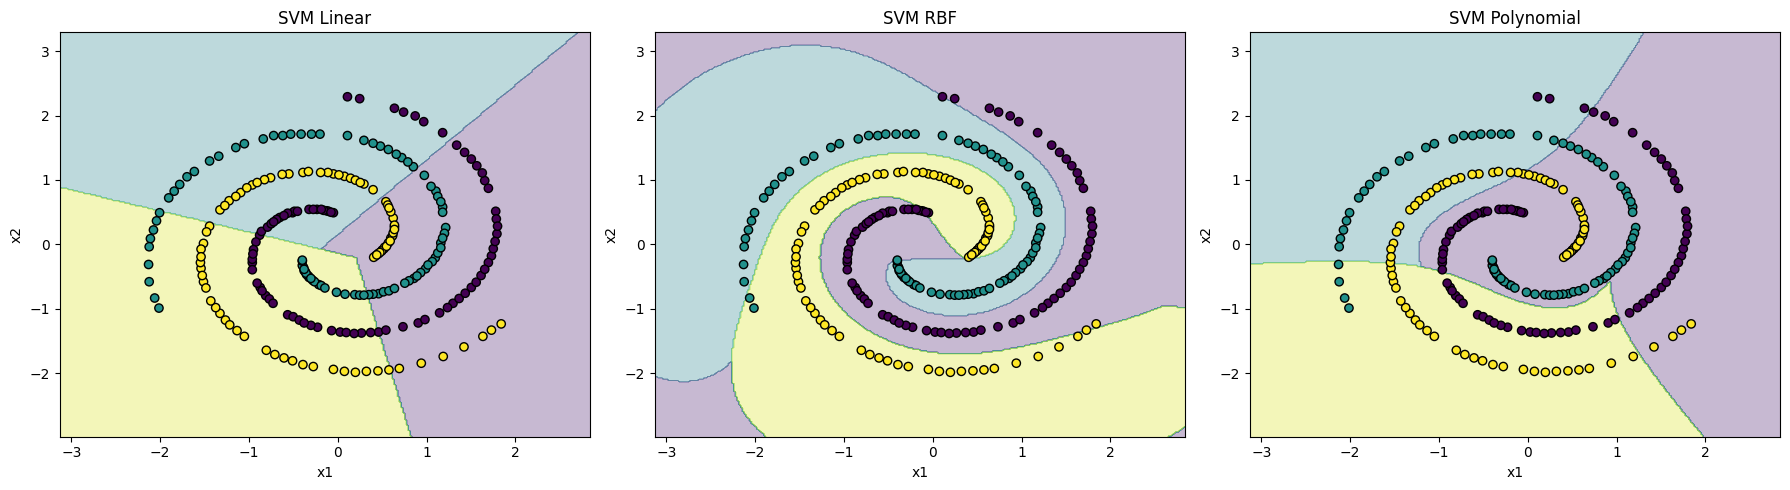

In [42]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary_subplot(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")


# === Plot 3 model dalam 1 gambar ===
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

plot_decision_boundary_subplot(model_linear, X_train_scaled, y_train, ax[0], "SVM Linear")
plot_decision_boundary_subplot(model_rbf, X_train_scaled, y_train, ax[1], "SVM RBF")
plot_decision_boundary_subplot(model_poly, X_train_scaled, y_train, ax[2], "SVM Polynomial")

plt.tight_layout()
plt.show()

# **10. 3D Visualisasi SVM (Linear, RBF, Polynomial)**

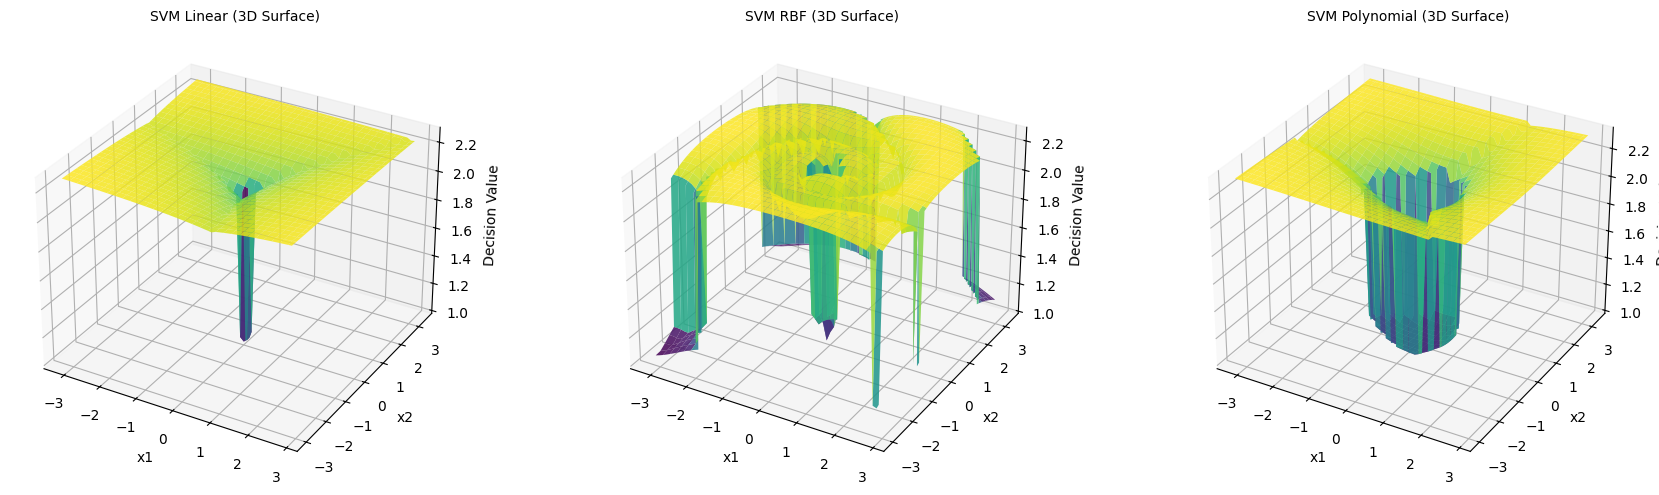

In [41]:
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

def plot_3d_surface_best(model, X, title, ax):
    # Buat grid untuk permukaan 3D
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 60),
                         np.linspace(y_min, y_max, 60))

    # Hitung decision function
    zz = model.decision_function(np.c_[xx.ravel(), yy.ravel()])

    # FIX untuk multi-class: ambil nilai keputusan paling dominan
    if len(zz.shape) > 1:
        zz = zz.max(axis=1)

    zz = zz.reshape(xx.shape)

    # Plot permukaan 3D
    ax.plot_surface(xx, yy, zz, cmap=cm.viridis, edgecolor='none', alpha=0.85)

    # Tambahkan contour garis batas di z=0
    ax.contour(xx, yy, zz, levels=[0], colors='red', linewidths=2)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("Decision Value")


# === Plot 3D untuk 3 model dalam 1 gambar ===
fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(131, projection='3d')
plot_3d_surface_best(model_linear, X_train_scaled, "SVM Linear (3D Surface)", ax1)

ax2 = fig.add_subplot(132, projection='3d')
plot_3d_surface_best(model_rbf, X_train_scaled, "SVM RBF (3D Surface)", ax2)

ax3 = fig.add_subplot(133, projection='3d')
plot_3d_surface_best(model_poly, X_train_scaled, "SVM Polynomial (3D Surface)", ax3)

plt.tight_layout()
plt.show()

# **11. Perbandingan Akurasi Model SVM Berdasarkan Kernel**

=== Perbandingan Akurasi Kernel SVM ===


,Kernel,Akurasi
0,Linear,0.269841
1,RBF,1.000000
2,Polynomial,0.396825


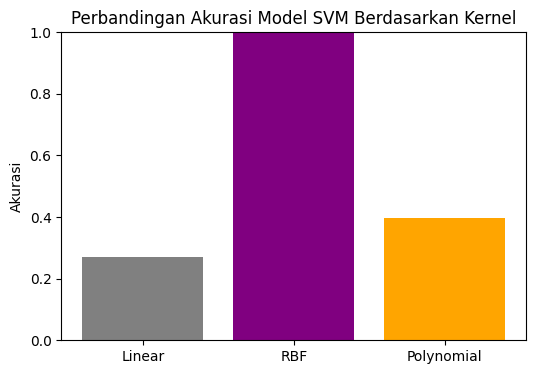

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Buat DataFrame Perbandingan Akurasi
accuracy_data = {
    "Kernel": ["Linear", "RBF", "Polynomial"],
    "Akurasi": [
        accuracy_score(y_test, y_pred_linear),
        accuracy_score(y_test, y_pred_rbf),
        accuracy_score(y_test, y_pred_poly)
    ]
}

df_accuracy = pd.DataFrame(accuracy_data)

print("=== Perbandingan Akurasi Kernel SVM ===")
display(df_accuracy)

# Plot Perbandingan Akurasi
plt.figure(figsize=(6,4))
plt.bar(df_accuracy["Kernel"], df_accuracy["Akurasi"], color=["gray", "purple", "orange"])
plt.title("Perbandingan Akurasi Model SVM Berdasarkan Kernel")
plt.ylabel("Akurasi")
plt.ylim(0,1)
plt.show()